PRM-KClosest - Basic Approach
===============================

Version | Author
------------ | -------------
0.3 | Björn Hein

License is based on Creative Commons: Attribution-NonCommercial 4.0 International (CC BY-NC 4.0) (pls. check: http://creativecommons.org/licenses/by-nc/4.0/)

This worksheet introduces a PRM variant that connects every sampled configuration to the `k` closest roadmap nodes. In contrast to the radius-based PRM, the number of connection attempts is controlled directly by `k`.

Important links are:

* General Info: http://www.python.org
* Python tutorial http://www.python.org/doc/tut/
* NetworkX http://networkx.github.io/
* NumPy and SciPy Guide http://docs.scipy.org/
* Matplotlib gallery https://matplotlib.org/stable/
* SciPy KDTree https://docs.scipy.org/doc/scipy/reference/generated/scipy.spatial.KDTree.html

Remember that you have to execute the code cells before their variables and classes can be used.


Setting up a KClosest PRM Algorithm
===================================

Needed functionality:

* Random position generator (sampling strategy)
* Computation of the `k` nearest neighbours for a given node
* Optional acceleration of nearest-neighbour queries with a KDTree
* Test of connected components
* Collision test for points and local connections
* Edge weights for weighted graph search


PRM-KClosest
============

The previous basic PRM connected nodes within a fixed radius. KClosest PRM uses a different control parameter:

* `k` determines how many nearby candidates are tested for every node.
* A small `k` produces sparse roadmaps and can fail to connect start and goal.
* A large `k` produces denser roadmaps, more collision checks, and usually better connectivity.
* `useKDTree=True` accelerates nearest-neighbour queries after all roadmap samples have been generated.

The planner still uses the same collision-checker interface as the other notebooks. The local planner resolution is passed through `config["collisionCheckingSteps"]`.


Definition of a base class for PRMs
===================================

The shared base class is defined in `IPPRMBase.py`. It provides random sampling inside the environment limits and rejection sampling until a collision-free configuration is found.

The planner implementation below extends this base class and follows the same `planPath(startList, goalList, config)` interface as the other planners.


Implementation
==============

The class below is also available as `IPKClosestPRM.py`. The implementation supports two roadmap-building strategies:

* `useKDTree=True`: sample all nodes first, then use `scipy.spatial.KDTree` to query nearest neighbours efficiently.
* `useKDTree=False`: build incrementally and find nearest neighbours by sorting the current graph nodes.

KDTree returns indices into the position array, not graph node IDs. Therefore the implementation keeps an explicit `nodeList` and maps KDTree indices back to graph nodes.


In [1]:
# %matplotlib inline


In [2]:
import heapq

import IPPRMBase
from IPPerfMonitor import IPPerfMonitor
import networkx as nx
import numpy as np

from scipy.spatial import KDTree
from scipy.spatial.distance import euclidean


class KClosestPRM(IPPRMBase.PRMBase):

    def __init__(self, _collChecker):
        super(KClosestPRM, self).__init__(_collChecker)
        self.graph = nx.Graph()

    @IPPerfMonitor
    def _inSameConnectedComponent(self, node1, node2):
        """Check whether two nodes are part of the same connected component."""
        for connectedComponent in nx.connected_components(self.graph):
            if (node1 in connectedComponent) and (node2 in connectedComponent):
                return True
        return False

    @IPPerfMonitor
    def _nearestNeighboursK(self, pos, k, excludeNode=None):
        """Find the k nearest graph nodes by brute force."""
        heap = list()
        for index, node in enumerate(self.graph.nodes(data=True)):
            if node[0] == excludeNode:
                continue
            heapq.heappush(heap, (euclidean(node[1]['pos'], pos), index, node))

        result = list()
        while len(heap) > 0 and len(result) < k:
            result.append(heapq.heappop(heap)[2])
        return result

    @IPPerfMonitor
    def _nearestNeighboursKSorted(self, pos, k, excludeNode=None):
        """Find the k nearest graph nodes by sorting all current nodes."""
        nodeList = [
            node for node in self.graph.nodes(data=True)
            if node[0] != excludeNode
        ]
        sortKey = lambda data: euclidean(pos, data[1]["pos"])
        return sorted(nodeList, key=sortKey)[:k]

    @IPPerfMonitor
    def _learnRoadmapNearestNeighbourKDTree(self, k, numNodes, collisionCheckingSteps=40):
        """Generate a roadmap and connect every node to its k nearest neighbours using a KDTree."""
        for nodeID in range(numNodes):
            self.graph.add_node(nodeID, pos=self._getRandomFreePosition())

        nodeList = list(self.graph.nodes())
        posList = [self.graph.nodes[node]["pos"] for node in nodeList]
        kdTree = KDTree(posList)

        for node in nodeList:
            queryK = min(k + 1, len(nodeList))
            distances, indices = kdTree.query(self.graph.nodes[node]['pos'], queryK)
            for dataIndex in np.atleast_1d(indices):
                neighbourNode = nodeList[int(dataIndex)]
                if neighbourNode == node:
                    continue
                if self._inSameConnectedComponent(node, neighbourNode):
                    continue

                nodePos = self.graph.nodes[node]['pos']
                neighbourPos = self.graph.nodes[neighbourNode]['pos']
                if not self._collisionChecker.lineInCollision(
                    nodePos, neighbourPos, steps=collisionCheckingSteps
                ):
                    self.graph.add_edge(
                        node,
                        neighbourNode,
                        weight=euclidean(nodePos, neighbourPos),
                    )

    @IPPerfMonitor
    def _learnRoadmapNearestNeighbour(self, k, numNodes, collisionCheckingSteps=40):
        """Generate a roadmap incrementally and connect every new node to up to k nearest neighbours."""
        nodeID = 1
        while nodeID <= numNodes:
            newNodePos = self._getRandomFreePosition()
            self.graph.add_node(nodeID, pos=newNodePos)

            result = self._nearestNeighboursKSorted(newNodePos, k, excludeNode=nodeID)

            for data in result:
                neighbourNode = data[0]
                neighbourPos = data[1]['pos']
                if self._inSameConnectedComponent(nodeID, neighbourNode):
                    continue

                if not self._collisionChecker.lineInCollision(
                    newNodePos, neighbourPos, steps=collisionCheckingSteps
                ):
                    self.graph.add_edge(
                        nodeID,
                        neighbourNode,
                        weight=euclidean(newNodePos, neighbourPos),
                    )

            nodeID += 1

    @IPPerfMonitor
    def planPath(self, startList, goalList, config):
        """
        Args:
            startList (list): list of possible start configurations
            goalList (list): list of possible goal configurations
            config (dict): planner configuration

        Example:
            config["k"] = 5
            config["numNodes"] = 300
            config["collisionCheckingSteps"] = 40
            config["useKDTree"] = True
        """
        self.graph.clear()
        collisionCheckingSteps = config.get("collisionCheckingSteps", 40)

        checkedStartList, checkedGoalList = self._checkStartGoal(startList, goalList)

        if config.get("useKDTree", True):
            self._learnRoadmapNearestNeighbourKDTree(
                config["k"],
                config["numNodes"],
                collisionCheckingSteps=collisionCheckingSteps,
            )
        else:
            self._learnRoadmapNearestNeighbour(
                config["k"],
                config["numNodes"],
                collisionCheckingSteps=collisionCheckingSteps,
            )

        result = self._nearestNeighboursK(checkedStartList[0], config["k"])
        for node in result:
            neighbourPos = node[1]['pos']
            if not self._collisionChecker.lineInCollision(
                checkedStartList[0], neighbourPos, steps=collisionCheckingSteps
            ):
                self.graph.add_node("start", pos=checkedStartList[0], color='lightgreen')
                self.graph.add_edge(
                    "start",
                    node[0],
                    weight=euclidean(checkedStartList[0], neighbourPos),
                )
                break

        result = self._nearestNeighboursK(checkedGoalList[0], config["k"])
        for node in result:
            neighbourPos = node[1]['pos']
            if not self._collisionChecker.lineInCollision(
                checkedGoalList[0], neighbourPos, steps=collisionCheckingSteps
            ):
                self.graph.add_node("goal", pos=checkedGoalList[0], color='lightgreen')
                self.graph.add_edge(
                    "goal",
                    node[0],
                    weight=euclidean(checkedGoalList[0], neighbourPos),
                )
                break

        try:
            path = nx.shortest_path(self.graph, "start", "goal", weight="weight")
        except (nx.NetworkXNoPath, nx.NodeNotFound):
            return []
        return path


## Visualizing the Information

The visualization draws the roadmap, emphasizes the largest connected component, and highlights the solution path if one was found.


In [3]:
import matplotlib.pyplot as plt

def basicPRMVisualize(graph, collChecker, solution, ax=None, nodeSize=300):
    """Draw graph, obstacles and solution in a matplotlib axis."""
    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 8))

    limits = collChecker.getEnvironmentLimits()
    ax.set_xlim(limits[0])
    ax.set_ylim(limits[1])
    ax.set_aspect("equal")
    ax.grid(True, linewidth=0.3)

    pos = nx.get_node_attributes(graph, 'pos')
    nx.draw(graph, pos, ax=ax, node_size=nodeSize)

    components = sorted(nx.connected_components(graph), key=len, reverse=True)
    if components:
        largestComponent = graph.subgraph(components[0])
        nx.draw_networkx_edges(
            largestComponent,
            pos,
            edge_color='y',
            width=nodeSize / 100.0,
            ax=ax,
        )
        nx.draw_networkx_labels(largestComponent, pos, font_size=nodeSize / 20.0, ax=ax)

        for component in components[1:]:
            if len(component) > 1:
                subgraph = graph.subgraph(component)
                nx.draw_networkx_edges(
                    subgraph,
                    pos,
                    edge_color='grey',
                    alpha=0.3,
                    width=nodeSize / 150.0,
                    ax=ax,
                )

    collChecker.drawObstacles(ax)

    if solution:
        solutionGraph = nx.subgraph(graph, solution)
        nx.draw_networkx_nodes(solutionGraph, pos, node_size=nodeSize, node_color='g', ax=ax)
        nx.draw_networkx_edges(solutionGraph, pos, alpha=0.8, edge_color='g', width=nodeSize / 30.0, ax=ax)

    if "start" in graph.nodes():
        nx.draw_networkx_nodes(graph, pos, nodelist=["start"], node_size=nodeSize, node_color='#00dd00', ax=ax)
        nx.draw_networkx_labels(graph, pos, labels={"start": "S"}, ax=ax)
    if "goal" in graph.nodes():
        nx.draw_networkx_nodes(graph, pos, nodelist=["goal"], node_size=nodeSize, node_color='#DD0000', ax=ax)
        nx.draw_networkx_labels(graph, pos, labels={"goal": "G"}, ax=ax)

    return ax


Simple Testing of the Algorithm
===============================

The configuration dictionary makes the planner parameters explicit. In this variant, `k` controls the number of nearest-neighbour candidates and `collisionCheckingSteps` controls the local planner resolution.


In [4]:
from shapely.geometry import Point, Polygon, LineString
from IPEnvironment import CollisionChecker

trapField = dict()
trapField["obs1"] = LineString([(6, 18), (6, 8), (16, 8), (16, 18)]).buffer(1.0)

environment = CollisionChecker(trapField)

basicPRM = KClosestPRM(environment)
basicConfig = dict()
basicConfig["k"] = 5
basicConfig["numNodes"] = 300
basicConfig["collisionCheckingSteps"] = 40
basicConfig["useKDTree"] = True

start = [[10, 10]]
goal = [[10, 1]]

IPPerfMonitor.clearData()

solution = basicPRM.planPath(start, goal, basicConfig)
print("solution:", solution)
print("path nodes:", len(solution))
print("roadmap nodes:", basicPRM.graph.number_of_nodes())
print("roadmap edges:", basicPRM.graph.number_of_edges())


solution: ['start', 58, 163, 129, 134, 9, 87, 161, 118, 201, 10, 145, 285, 90, 50, 147, 72, 96, 206, 60, 258, 39, 159, 75, 67, 88, 20, 117, 11, 0, 17, 82, 21, 175, 2, 36, 299, 48, 25, 5, 64, 1, 226, 19, 102, 109, 245, 14, 7, 99, 51, 100, 73, 152, 81, 'goal']
path nodes: 56
roadmap nodes: 302
roadmap edges: 301


Text(0.5, 1.0, 'KClosest PRM with KDTree')

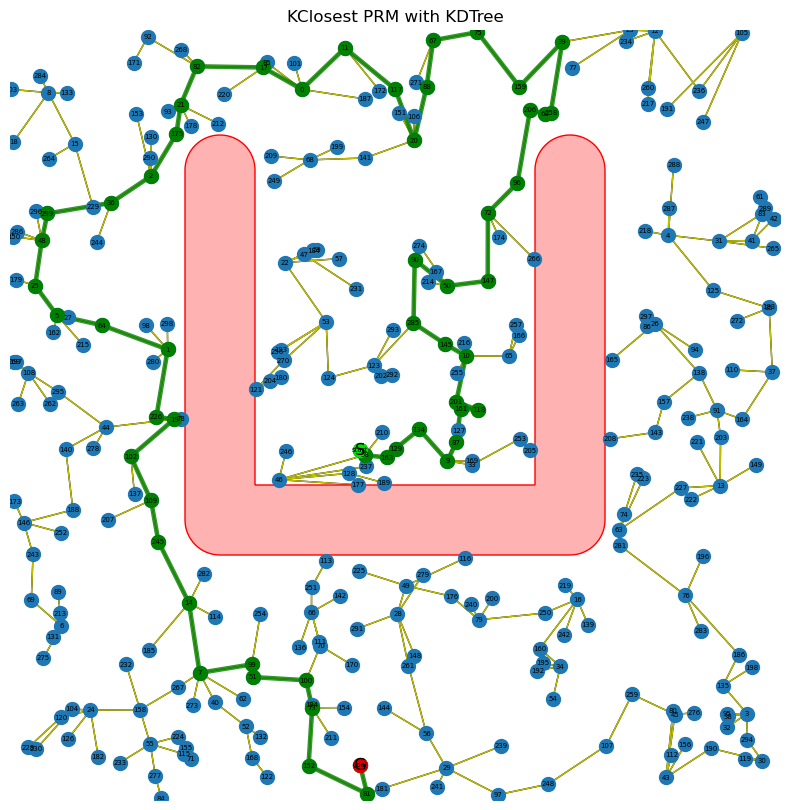

In [5]:
fig_local = plt.figure(figsize=(10, 10))
ax = fig_local.add_subplot(1, 1, 1)
basicPRMVisualize(basicPRM.graph, environment, solution, ax=ax, nodeSize=100)
ax.set_title("KClosest PRM with KDTree")


Playground
==========

Try different values of `k`, `numNodes`, `collisionCheckingSteps`, and `useKDTree`.

Important observations:

* Increasing `k` usually improves connectivity but increases collision checks.
* Increasing `numNodes` improves coverage but increases roadmap size.
* Increasing `collisionCheckingSteps` makes local collision checks finer but more expensive.
* `useKDTree=True` and `useKDTree=False` build the roadmap differently, but both use the same `planPath` interface.


## Comparing KDTree and Incremental Sorting

Both variants use `k` closest candidates. The KDTree variant samples all roadmap nodes first and then connects them. The incremental variant connects every new sample to the nearest nodes that already exist in the graph.

The plots below use the same configuration for both variants and show how the roadmap structure can differ even though the public planner interface stays the same.


useKDTree= True solution nodes= 33 geometric length= 62.45 roadmap edges= 201
useKDTree= False solution nodes= 18 geometric length= 69.39 roadmap edges= 201


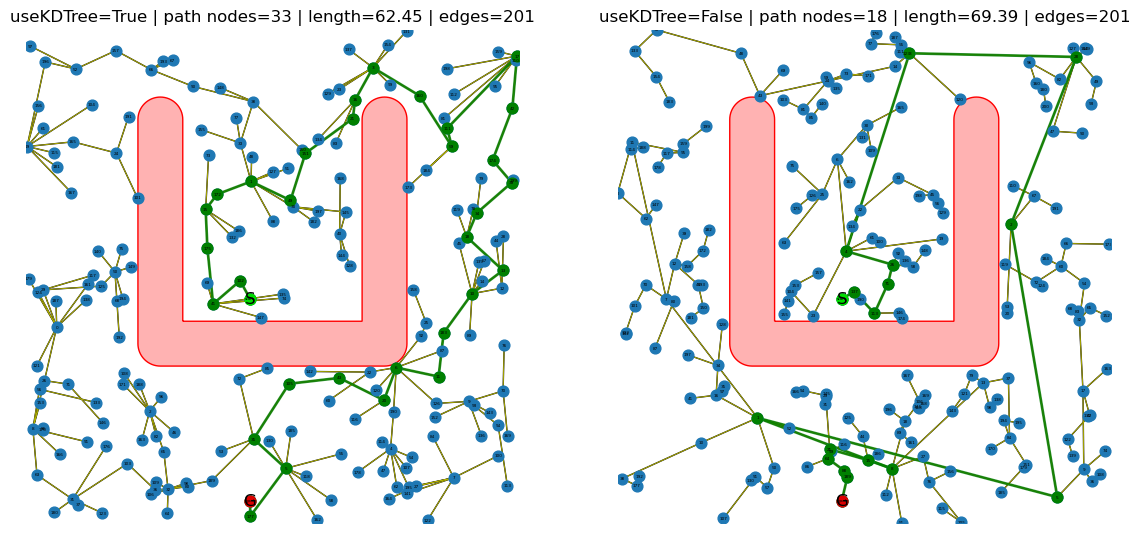

In [6]:
def pathLength(graph, path):
    if not path:
        return None
    return sum(graph[path[i]][path[i + 1]]["weight"] for i in range(len(path) - 1))

comparisonResults = []

fig, axes = plt.subplots(1, 2, figsize=(14, 7))
for ax, useKDTree in zip(axes, [True, False]):
    planner = KClosestPRM(environment)
    config = dict(basicConfig)
    config["useKDTree"] = useKDTree
    config["numNodes"] = 200
    config["k"] = 8
    solution = planner.planPath(start, goal, config)
    geometricLength = pathLength(planner.graph, solution)

    comparisonResults.append((useKDTree, planner, solution, geometricLength))
    basicPRMVisualize(planner.graph, environment, solution, ax=ax, nodeSize=60)
    lengthText = "no path" if geometricLength is None else "length={:.2f}".format(geometricLength)
    ax.set_title(
        "useKDTree={} | path nodes={} | {} | edges={}".format(
            useKDTree,
            len(solution),
            lengthText,
            planner.graph.number_of_edges(),
        )
    )

for useKDTree, planner, solution, geometricLength in comparisonResults:
    lengthText = "no path" if geometricLength is None else "{:.2f}".format(geometricLength)
    print(
        "useKDTree=", useKDTree,
        "solution nodes=", len(solution),
        "geometric length=", lengthText,
        "roadmap edges=", planner.graph.number_of_edges(),
    )


## Reusing the Planner

For later notebooks or scripts, import the class from `IPKClosestPRM.py` instead of redefining it in a notebook:

```python
from IPKClosestPRM import KClosestPRM
```
